In [4]:
# Cell 1: Install all dependencies
!pip install nibabel monai scikit-learn matplotlib seaborn tqdm torch torchvision pydicom
!pip install git+https://github.com/MIC-DKFZ/HD-BET

  Cloning https://github.com/MIC-DKFZ/HD-BET to /tmp/pip-req-build-vu2vhn0x
  Running command git clone --filter=blob:none --quiet https://github.com/MIC-DKFZ/HD-BET /tmp/pip-req-build-vu2vhn0x
  Resolved https://github.com/MIC-DKFZ/HD-BET to commit 678e44d546a84de0f2a7fc245f176b82b7d912fd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [5]:
# Cell 2: Mount Drive and setup directories
from google.colab import drive
drive.mount('/content/drive')

import os

ZIP_PATH   = '/content/drive/MyDrive/MRI.zip'
EXTRACT_TO = '/content/dataset'
OUTPUT_DIR = '/content/preprocessed'

os.makedirs(EXTRACT_TO, exist_ok=True)
for split in ['train', 'val', 'test']:
    for cls in ['CN', 'MCI', 'AD']:
        os.makedirs(f'{OUTPUT_DIR}/{split}/{cls}', exist_ok=True)

print("✅ Directories created")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Directories created


In [3]:
# Cell 3: Extract dataset ZIP
import zipfile

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)
    print(f"✅ Extracted {len(z.namelist())} files")

✅ Extracted 64011 files


In [6]:
# Cell 4: Load CSV metadata and match DICOM folders
import pandas as pd
import os

CSV_PATH = '/content/drive/MyDrive/MRI_metadata.csv'
df = pd.read_csv(CSV_PATH)
DATASET_MRI_DIR = '/content/dataset/MRI'

# Index all DICOM folders by ImageID
all_dcm_folders = {}
for subject_dir in os.listdir(DATASET_MRI_DIR):
    subject_path = os.path.join(DATASET_MRI_DIR, subject_dir)
    if not os.path.isdir(subject_path): continue
    for scan_type in os.listdir(subject_path):
        scan_path = os.path.join(subject_path, scan_type)
        if not os.path.isdir(scan_path): continue
        for date_dir in os.listdir(scan_path):
            date_path = os.path.join(scan_path, date_dir)
            if not os.path.isdir(date_path): continue
            for image_id in os.listdir(date_path):
                image_path = os.path.join(date_path, image_id)
                if os.path.isdir(image_path):
                    all_dcm_folders[image_id] = image_path

def find_dicom_folder(image_id):
    return all_dcm_folders.get(image_id, None)

df['folder_path'] = df['ImageID'].apply(find_dicom_folder)
matched = df.dropna(subset=['folder_path']).copy()
print(f"✅ Matched: {len(matched)} total scans")
print(matched['Group'].value_counts())

✅ Matched: 383 total scans
Group
MCI    180
CN     121
AD      82
Name: count, dtype: int64


In [7]:
# Cell 5: Subject-level train/val/test split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss.split(matched, matched['Group'], groups=matched['Subject']))
train_df = matched.iloc[train_idx]
temp_df  = matched.iloc[temp_idx]

gss_temp = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss_temp.split(temp_df, temp_df['Group'], groups=temp_df['Subject']))
val_df  = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print(f"Train scans : {len(train_df)}")
print(f"Val scans   : {len(val_df)}")
print(f"Test scans  : {len(test_df)}")

# Verify no subject leakage between splits
train_subjects = set(train_df['Subject'])
val_subjects   = set(val_df['Subject'])
test_subjects  = set(test_df['Subject'])
assert len(train_subjects & val_subjects) == 0, "❌ Subject leakage: train/val"
assert len(train_subjects & test_subjects) == 0, "❌ Subject leakage: train/test"
assert len(val_subjects & test_subjects) == 0, "❌ Subject leakage: val/test"
print("✅ No subject leakage between splits")

Train scans : 263
Val scans   : 61
Test scans  : 59
✅ No subject leakage between splits


In [8]:
# Cell 6: Convert all DICOM folders to NIfTI first (batch, no HD-BET yet)
import os
import numpy as np
import nibabel as nib
import pydicom
import glob
import torch
import torch.nn.functional as F
import subprocess
from tqdm import tqdm

TARGET_SHAPE = (128, 128, 128)
NIFTI_DIR    = '/content/nifti_raw'       # raw NIfTI before skull stripping
STRIPPED_DIR = '/content/nifti_stripped'  # HD-BET output
os.makedirs(NIFTI_DIR,    exist_ok=True)
os.makedirs(STRIPPED_DIR, exist_ok=True)

def load_dicom_volume(folder_path):
    all_files = sorted(glob.glob(f'{folder_path}/**/*', recursive=True))
    dcm_files = [f for f in all_files if os.path.isfile(f)]
    if not dcm_files:
        raise ValueError(f"No files in {folder_path}")

    slices, positions = [], []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(f, force=True)
            if not hasattr(ds, "pixel_array"): continue
            arr = ds.pixel_array.astype(np.float32)
            if arr.std() < 5: continue
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
            slices.append(arr)
            if hasattr(ds, "InstanceNumber"):
                positions.append(int(ds.InstanceNumber))
            elif hasattr(ds, "ImagePositionPatient"):
                positions.append(float(ds.ImagePositionPatient[2]))
            else:
                positions.append(len(positions))
        except:
            continue

    if len(slices) < 10:
        raise ValueError(f"Too few slices: {len(slices)}")

    sorted_idx = np.argsort(np.array(positions))
    slices     = [slices[i] for i in sorted_idx]
    min_h      = min(s.shape[0] for s in slices)
    min_w      = min(s.shape[1] for s in slices)
    slices     = [s[:min_h, :min_w] for s in slices]
    return np.stack(slices, axis=-1)


print("⏳ Step 1: Converting DICOM → NIfTI for all subjects...")
all_rows   = pd.concat([train_df, val_df, test_df]).drop_duplicates(subset='ImageID')
ok, failed = 0, []

for _, row in tqdm(all_rows.iterrows(), total=len(all_rows), desc="DICOM→NIfTI"):
    out_path = f"{NIFTI_DIR}/{row['ImageID']}.nii.gz"
    if os.path.exists(out_path):   # skip if already done
        ok += 1
        continue
    try:
        vol     = load_dicom_volume(row['folder_path'])
        vol     = np.clip(vol, np.percentile(vol, 1), np.percentile(vol, 99))
        nib.save(nib.Nifti1Image(vol, affine=np.eye(4)), out_path)
        ok += 1
    except Exception as e:
        failed.append((row['ImageID'], str(e)))

print(f"✅ NIfTI saved: {ok}  ❌ Failed: {len(failed)}")
if failed:
    print("Failed:", failed[:5])

⏳ Step 1: Converting DICOM → NIfTI for all subjects...


DICOM→NIfTI: 100%|██████████| 383/383 [10:37<00:00,  1.66s/it]

✅ NIfTI saved: 383  ❌ Failed: 0


In [9]:
# Cell 7: Run HD-BET once on entire folder — much faster than per-subject
print("⏳ Step 2: Running HD-BET in batch mode...")

# HD-BET batch: point it at the input folder, outputs go to STRIPPED_DIR
command = f"hd-bet -i {NIFTI_DIR} -o {STRIPPED_DIR} -device cuda:0 --disable_tta"
result  = subprocess.run(command, shell=True, capture_output=True, text=True)

if result.returncode != 0:
    print(f"❌ HD-BET batch failed:\n{result.stderr[:500]}")
else:
    stripped_files = [f for f in os.listdir(STRIPPED_DIR) if f.endswith('.nii.gz') and 'mask' not in f]
    print(f"✅ HD-BET batch complete! Stripped files: {len(stripped_files)}")

⏳ Step 2: Running HD-BET in batch mode...
✅ HD-BET batch complete! Stripped files: 383


In [10]:
# Cell 8: Normalize + resize stripped NIfTIs → save as .npy per split
print("⏳ Step 3: Saving preprocessed splits...")

def postprocess_and_save(split_df, split_name):
    ok, skipped, errors = 0, 0, []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        save_path = f"{OUTPUT_DIR}/{split_name}/{row['Group']}/{row['ImageID']}.npy"

        if os.path.exists(save_path):   # skip already done
            skipped += 1
            ok += 1
            continue

        # Try stripped version first, fall back to raw NIfTI
        stripped_path = f"{STRIPPED_DIR}/{row['ImageID']}.nii.gz"
        raw_path      = f"{NIFTI_DIR}/{row['ImageID']}.nii.gz"

        try:
            if os.path.exists(stripped_path):
                volume = nib.load(stripped_path).get_fdata().astype(np.float32)
            elif os.path.exists(raw_path):
                print(f"  ⚠️ No stripped file for {row['ImageID']}, using raw NIfTI")
                volume = nib.load(raw_path).get_fdata().astype(np.float32)
            else:
                errors.append((row['ImageID'], 'no NIfTI found'))
                continue

            # Z-score normalize within brain mask
            brain_mask = volume > 0
            if brain_mask.sum() > 0:
                mean, std = volume[brain_mask].mean(), volume[brain_mask].std()
                if std > 1e-6:
                    volume[brain_mask] = (volume[brain_mask] - mean) / std

            # Resize to target shape
            tensor  = torch.tensor(volume).unsqueeze(0).unsqueeze(0)
            resized = F.interpolate(tensor, size=TARGET_SHAPE, mode='trilinear', align_corners=False)
            volume  = resized.squeeze().numpy()

            if volume.max() == 0:
                errors.append((row['ImageID'], 'black image'))
                continue

            np.save(save_path, volume)
            ok += 1

        except Exception as e:
            errors.append((row['ImageID'], str(e)))

    print(f"  ✅ Saved: {ok}  ⏭ Skipped: {skipped}  ❌ Errors: {len(errors)}")
    if errors:
        print(f"  Errors: {errors[:5]}")

postprocess_and_save(train_df, 'train')
postprocess_and_save(val_df,   'val')
postprocess_and_save(test_df,  'test')

print("\n📦 Zipping to Google Drive...")
!zip -r /content/drive/MyDrive/MRI_Preprocessed_Final.zip /content/preprocessed
print("✅ All done!")

⏳ Step 3: Saving preprocessed splits...


train: 100%|██████████| 263/263 [02:28<00:00,  1.77it/s]


  ✅ Saved: 263  ⏭ Skipped: 0  ❌ Errors: 0


val: 100%|██████████| 61/61 [00:34<00:00,  1.77it/s]


  ✅ Saved: 61  ⏭ Skipped: 0  ❌ Errors: 0


test: 100%|██████████| 59/59 [00:32<00:00,  1.80it/s]


  ✅ Saved: 59  ⏭ Skipped: 0  ❌ Errors: 0

📦 Zipping to Google Drive...
  adding: content/preprocessed/ (stored 0%)
  adding: content/preprocessed/test/ (stored 0%)
  adding: content/preprocessed/test/MCI/ (stored 0%)
  adding: content/preprocessed/test/MCI/I8248.npy (deflated 88%)
  adding: content/preprocessed/test/MCI/I36695.npy (deflated 88%)
  adding: content/preprocessed/test/MCI/I45610.npy (deflated 89%)
  adding: content/preprocessed/test/MCI/I8249.npy (deflated 88%)
  adding: content/preprocessed/test/MCI/I36803.npy (deflated 87%)
  adding: content/preprocessed/test/MCI/I17512.npy (deflated 91%)
  adding: content/preprocessed/test/MCI/I36702.npy (deflated 90%)
  adding: content/preprocessed/test/MCI/I17420.npy (deflated 89%)
  adding: content/preprocessed/test/MCI/I36802.npy (deflated 87%)
  adding: content/preprocessed/test/MCI/I36696.npy (deflated 88%)
  adding: content/preprocessed/test/MCI/I17419.npy (deflated 89%)
  adding: content/preprocessed/test/MCI/I16848.npy (deflate

In [15]:
# Cell 9: MRI 2.5D Dataset — fixed augmentation + ImageNet normalization
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class MRIDataset25D(Dataset):
    def __init__(self, root_dir, classes, augment=False):
        self.samples      = []
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.augment      = augment

        # ✅ ImageNet normalization (required since we use pretrained ResNet18)
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )

        for cls in classes:
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder): continue
            for f in os.listdir(folder):
                if f.endswith('.npy'):
                    self.samples.append((os.path.join(folder, f), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        vol = np.load(path).astype(np.float32)  # shape: (H, W, D)

        D      = vol.shape[2]
        mid    = D // 2
        offset = 5

        if self.augment and np.random.rand() > 0.5:
            mid = mid + np.random.randint(-3, 4)

        mid = max(offset, min(mid, D - offset - 1))

        # Extract 2.5D slab (3 slices as RGB-like channels)
        sl_1 = vol[:, :, mid - offset]
        sl_2 = vol[:, :, mid]
        sl_3 = vol[:, :, mid + offset]

        img = np.stack([sl_1, sl_2, sl_3], axis=0)  # shape: (3, H, W)

        if self.augment:
            # ✅ Fixed: use np.array() to avoid read-only issues after flip
            if np.random.rand() > 0.5:
                img = np.array(np.flip(img, axis=2))
            if np.random.rand() > 0.5:
                img = img + np.random.normal(0, 0.03, img.shape).astype(np.float32)

        tensor = torch.tensor(img, dtype=torch.float32)

        # ✅ Clip to [0,1] before ImageNet normalization
        tensor = torch.clamp(tensor, 0, 1)
        tensor = self.normalize(tensor)

        return tensor, torch.tensor(label, dtype=torch.long)

# Verify
ds_train = MRIDataset25D(f'{OUTPUT_DIR}/train', ['CN', 'MCI', 'AD'], augment=True)
ds_val   = MRIDataset25D(f'{OUTPUT_DIR}/val',   ['CN', 'MCI', 'AD'], augment=False)
ds_test  = MRIDataset25D(f'{OUTPUT_DIR}/test',  ['CN', 'MCI', 'AD'], augment=False)
print(f"✅ Train: {len(ds_train)} | Val: {len(ds_val)} | Test: {len(ds_test)}")

✅ Train: 263 | Val: 61 | Test: 59


In [16]:
# Cell 10: Model definition + training + evaluation
import torch
import torch.nn as nn
import copy
import numpy as np
from torchvision import models
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             f1_score, precision_score, recall_score, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

def get_resnet_model(num_classes):
    weights = models.ResNet18_Weights.DEFAULT
    model   = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def evaluate_model(model, dataloader, device, num_classes, task_name):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_probs  = np.array(all_probs)   # ✅ Fixed: must be np.array for roc_auc_score
    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1  = f1_score(all_labels, all_preds, average='macro')
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)

    if num_classes == 2:
        auc = roc_auc_score(all_labels, all_probs[:, 1])
    else:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

    print(f"\n=== {task_name} Evaluation ===")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"AUC               : {auc:.4f}")
    print(f"Macro F1-Score    : {macro_f1:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{task_name} - Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return bal_acc


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, save_path):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model  = model.to(device)

    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            loader          = train_loader if phase == 'train' else val_loader
            running_loss    = 0.0
            running_correct = 0

            for inputs, labels in loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs     = model(inputs)
                    _, preds    = torch.max(outputs, 1)
                    loss        = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss    += loss.item() * inputs.size(0)
                running_correct += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(loader.dataset)
            epoch_acc  = running_correct.double() / len(loader.dataset)
            print(f"  {phase.capitalize():5s} — Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}")

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), save_path)
                print(f"  🌟 New best model saved (Val Acc: {best_acc:.4f})")

    print(f"\n✅ Training complete. Best Val Acc: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model, device

print("✅ Model and training functions defined")

✅ Model and training functions defined


🚀 Task 2: Binary Classification — CN vs AD
Train: 126 | Val: 36 | Test: 41

Epoch 1/15
  Train — Loss: 0.7279  Acc: 0.5952
  Val   — Loss: 0.7962  Acc: 0.5556
  🌟 New best model saved (Val Acc: 0.5556)

Epoch 2/15
  Train — Loss: 0.5365  Acc: 0.7222
  Val   — Loss: 0.9863  Acc: 0.5556

Epoch 3/15
  Train — Loss: 0.4696  Acc: 0.7778
  Val   — Loss: 0.8710  Acc: 0.5278

Epoch 4/15
  Train — Loss: 0.4020  Acc: 0.8016
  Val   — Loss: 0.9255  Acc: 0.6389
  🌟 New best model saved (Val Acc: 0.6389)

Epoch 5/15
  Train — Loss: 0.3600  Acc: 0.8492
  Val   — Loss: 1.1051  Acc: 0.5000

Epoch 6/15
  Train — Loss: 0.2455  Acc: 0.8968
  Val   — Loss: 1.3776  Acc: 0.5278

Epoch 7/15
  Train — Loss: 0.1821  Acc: 0.9048
  Val   — Loss: 1.5347  Acc: 0.5000

Epoch 8/15
  Train — Loss: 0.1273  Acc: 0.9603
  Val   — Loss: 1.6682  Acc: 0.5556

Epoch 9/15
  Train — Loss: 0.1472  Acc: 0.9365
  Val   — Loss: 1.5430  Acc: 0.5556

Epoch 10/15
  Train — Loss: 0.1880  Acc: 0.9286
  Val   — Loss: 1.6539  Acc: 0.611

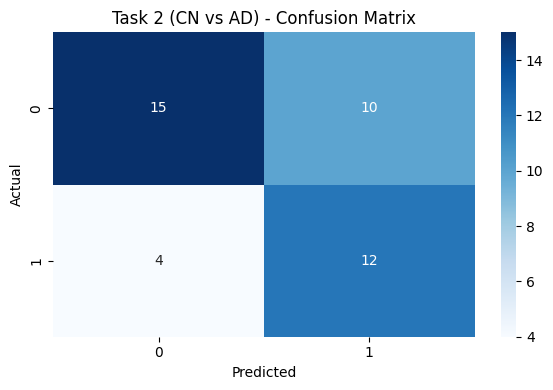

np.float64(0.675)

In [17]:
# Cell 11: Binary classification — CN vs AD
from torch.utils.data import DataLoader
import torch.optim as optim

print("🚀 Task 2: Binary Classification — CN vs AD")

binary_classes = ['CN', 'AD']
b_train_ds = MRIDataset25D(f'{OUTPUT_DIR}/train', binary_classes, augment=True)
b_val_ds   = MRIDataset25D(f'{OUTPUT_DIR}/val',   binary_classes, augment=False)
b_test_ds  = MRIDataset25D(f'{OUTPUT_DIR}/test',  binary_classes, augment=False)

# ✅ Fixed: num_workers=0 avoids Colab multiprocessing deadlocks
b_train_loader = DataLoader(b_train_ds, batch_size=16, shuffle=True,  num_workers=0)
b_val_loader   = DataLoader(b_val_ds,   batch_size=16, shuffle=False, num_workers=0)
b_test_loader  = DataLoader(b_test_ds,  batch_size=16, shuffle=False, num_workers=0)

print(f"Train: {len(b_train_ds)} | Val: {len(b_val_ds)} | Test: {len(b_test_ds)}")

binary_model  = get_resnet_model(num_classes=2)
criterion     = nn.CrossEntropyLoss()
optimizer     = optim.AdamW(binary_model.parameters(), lr=1e-4, weight_decay=1e-2)

binary_model_path = '/content/drive/MyDrive/binary_cn_ad_model.pth'
binary_model, device = train_model(
    binary_model, b_train_loader, b_val_loader,
    criterion, optimizer,
    num_epochs=15, save_path=binary_model_path
)

print("\n🧪 Final Test Evaluation:")
evaluate_model(binary_model, b_test_loader, device, num_classes=2, task_name="Task 2 (CN vs AD)")

🚀 Task 3: Multi-Class Classification — CN vs MCI vs AD
Train: 263 | Val: 61 | Test: 59

Epoch 1/20
  Train — Loss: 1.1309  Acc: 0.4221
  Val   — Loss: 1.2192  Acc: 0.3279
  🌟 New best model saved (Val Acc: 0.3279)

Epoch 2/20
  Train — Loss: 0.8928  Acc: 0.5970
  Val   — Loss: 1.1553  Acc: 0.5082
  🌟 New best model saved (Val Acc: 0.5082)

Epoch 3/20
  Train — Loss: 0.7604  Acc: 0.6730
  Val   — Loss: 1.4421  Acc: 0.4262

Epoch 4/20
  Train — Loss: 0.5953  Acc: 0.7529
  Val   — Loss: 1.5380  Acc: 0.3934

Epoch 5/20
  Train — Loss: 0.5413  Acc: 0.8099
  Val   — Loss: 1.4324  Acc: 0.3607

Epoch 6/20
  Train — Loss: 0.4513  Acc: 0.8251
  Val   — Loss: 1.8690  Acc: 0.2951

Epoch 7/20
  Train — Loss: 0.3568  Acc: 0.8631
  Val   — Loss: 2.1183  Acc: 0.4098

Epoch 8/20
  Train — Loss: 0.2957  Acc: 0.8897
  Val   — Loss: 1.7423  Acc: 0.4262

Epoch 9/20
  Train — Loss: 0.3613  Acc: 0.8555
  Val   — Loss: 1.7972  Acc: 0.3934

Epoch 10/20
  Train — Loss: 0.2910  Acc: 0.8821
  Val   — Loss: 1.8951

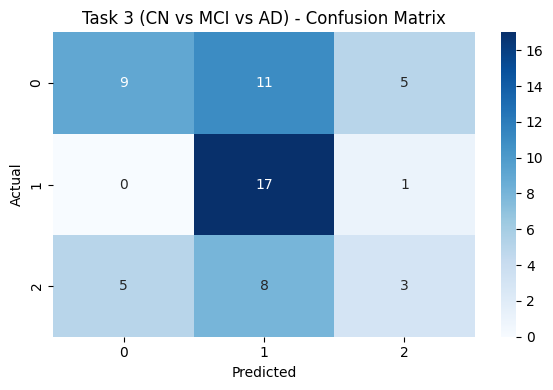

np.float64(0.4973148148148148)

In [14]:
# Cell 12: Multi-class classification — CN vs MCI vs AD
print("🚀 Task 3: Multi-Class Classification — CN vs MCI vs AD")

multi_classes = ['CN', 'MCI', 'AD']
m_train_ds = MRIDataset25D(f'{OUTPUT_DIR}/train', multi_classes, augment=True)
m_val_ds   = MRIDataset25D(f'{OUTPUT_DIR}/val',   multi_classes, augment=False)
m_test_ds  = MRIDataset25D(f'{OUTPUT_DIR}/test',  multi_classes, augment=False)

# ✅ Fixed: num_workers=0
m_train_loader = DataLoader(m_train_ds, batch_size=16, shuffle=True,  num_workers=0)
m_val_loader   = DataLoader(m_val_ds,   batch_size=16, shuffle=False, num_workers=0)
m_test_loader  = DataLoader(m_test_ds,  batch_size=16, shuffle=False, num_workers=0)

print(f"Train: {len(m_train_ds)} | Val: {len(m_val_ds)} | Test: {len(m_test_ds)}")

multi_model   = get_resnet_model(num_classes=3)
criterion     = nn.CrossEntropyLoss()
optimizer     = optim.AdamW(multi_model.parameters(), lr=1e-4, weight_decay=1e-2)

multi_model_path = '/content/drive/MyDrive/multiclass_cn_mci_ad_model.pth'
multi_model, device = train_model(
    multi_model, m_train_loader, m_val_loader,
    criterion, optimizer,
    num_epochs=20, save_path=multi_model_path
)

print("\n🧪 Final Test Evaluation:")
evaluate_model(multi_model, m_test_loader, device, num_classes=3, task_name="Task 3 (CN vs MCI vs AD)")

📊  CerebroAI — Evaluation Report (Test Results Only)

⏳ Computing test metrics & extracting deep features for all tasks...
✅ Metrics ready

── Binary Classification Report (Test) ──────────────────────
              precision    recall  f1-score   support

          CN       0.79      0.60      0.68        25
          AD       0.55      0.75      0.63        16

    accuracy                           0.66        41
   macro avg       0.67      0.68      0.66        41
weighted avg       0.69      0.66      0.66        41


── Multiclass Classification Report (Test) ───────────────────
              precision    recall  f1-score   support

          CN       0.64      0.36      0.46        25
         MCI       0.47      0.94      0.63        18
          AD       0.33      0.19      0.24        16

    accuracy                           0.49        59
   macro avg       0.48      0.50      0.44        59
weighted avg       0.51      0.49      0.45        59


⏳ Rendering figures...



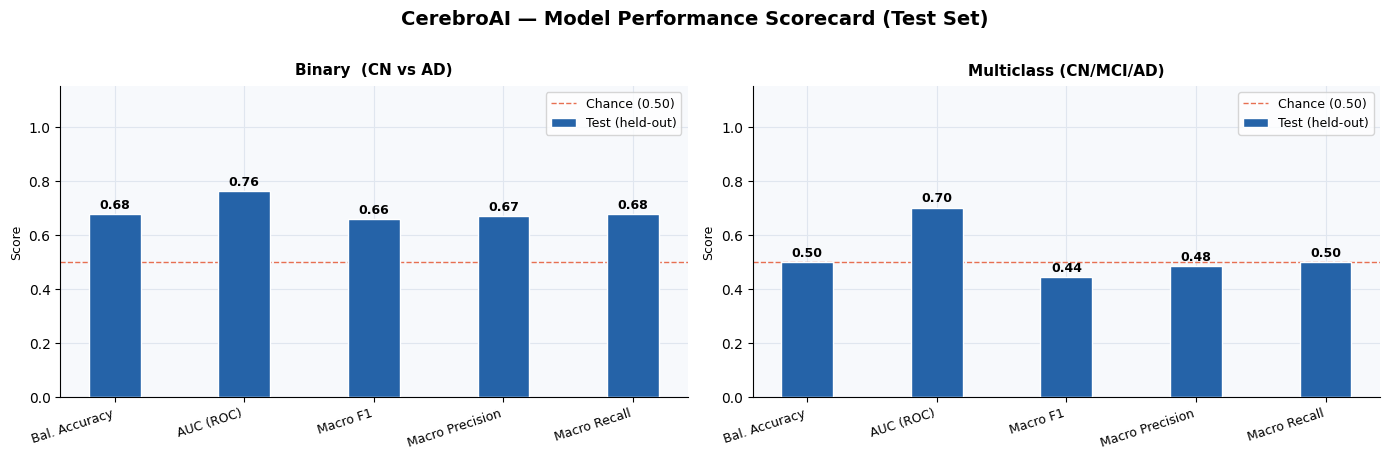

✅ Fig 1/7 — Scorecard


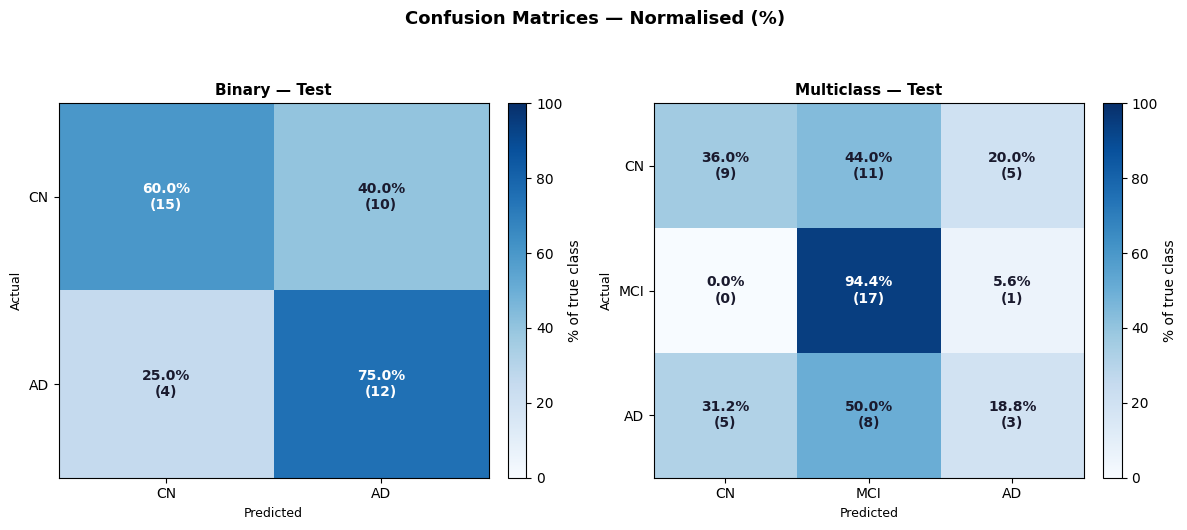

✅ Fig 2/7 — Confusion Matrices


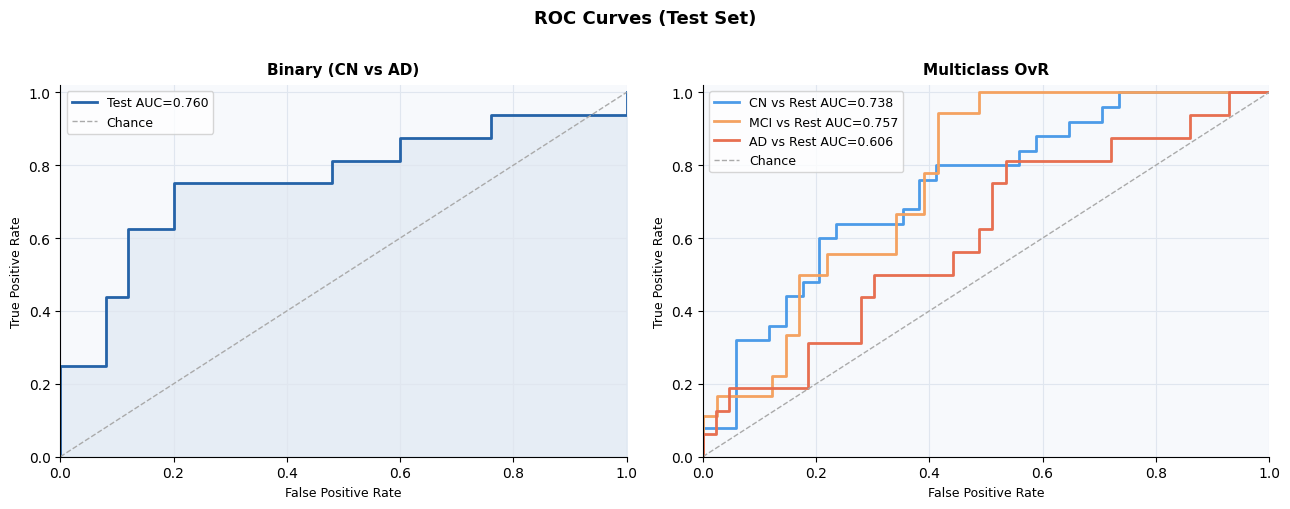

✅ Fig 3/7 — ROC Curves


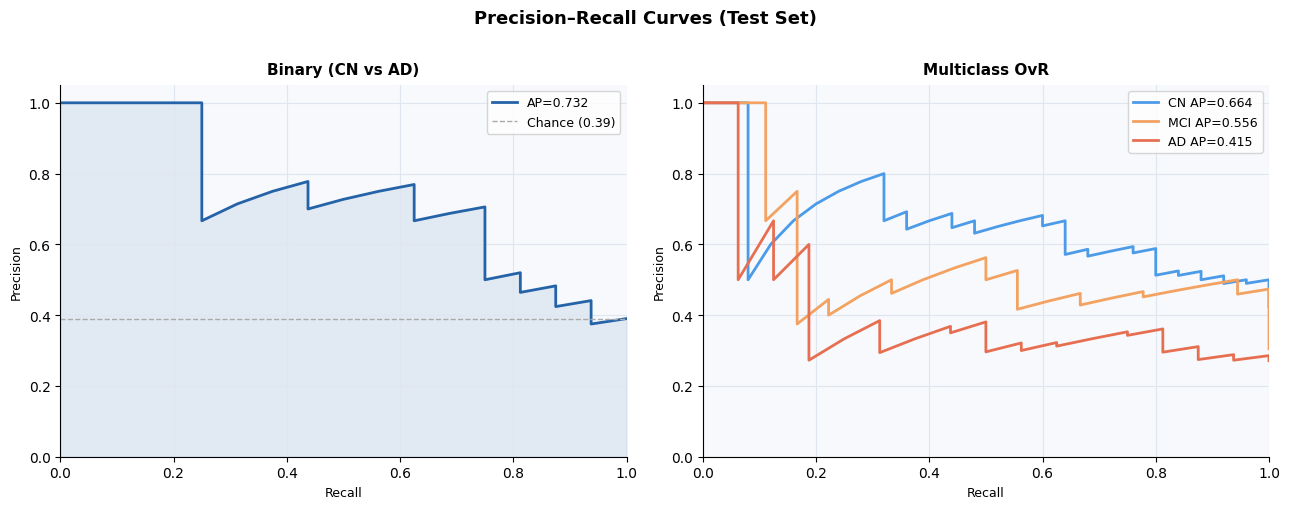

✅ Fig 4/7 — Precision-Recall Curves


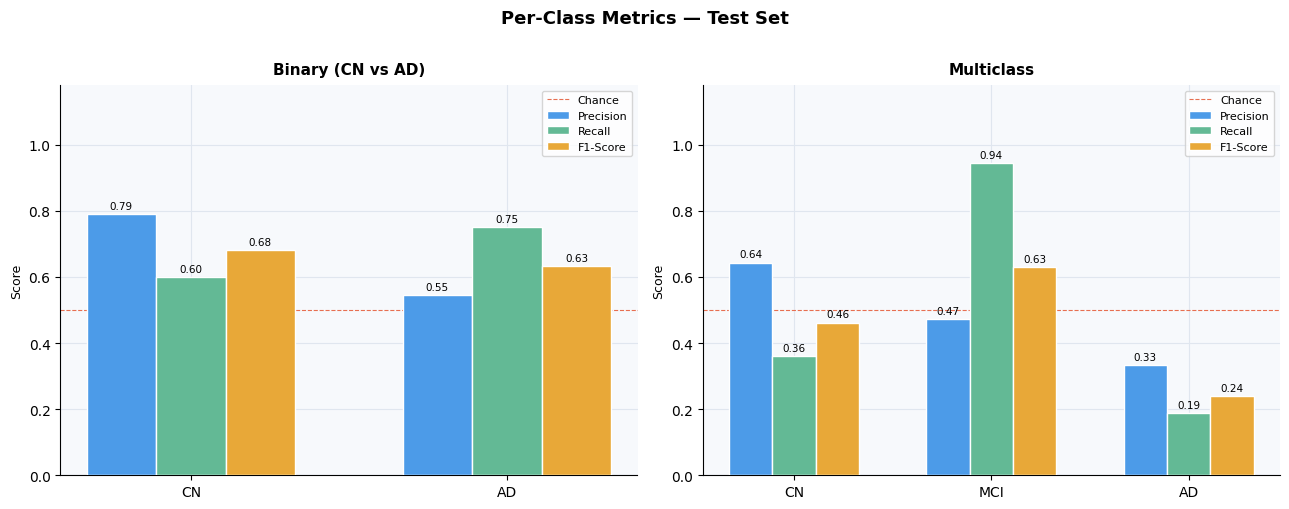

✅ Fig 5/7 — Per-Class Metrics


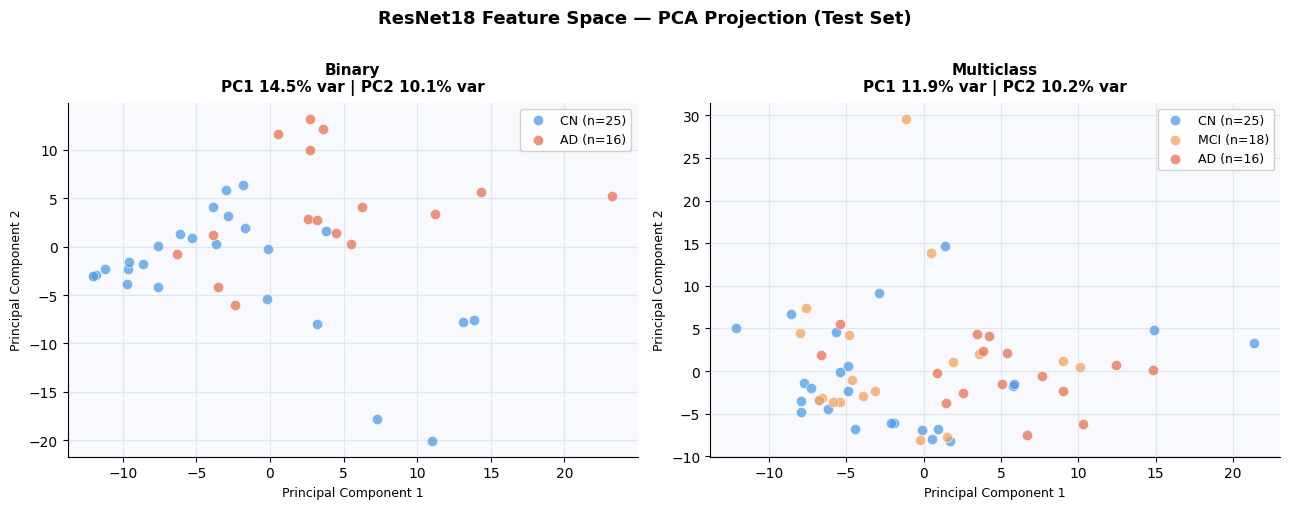

✅ Fig 6/7 — Deep Feature Space (PCA 2D)


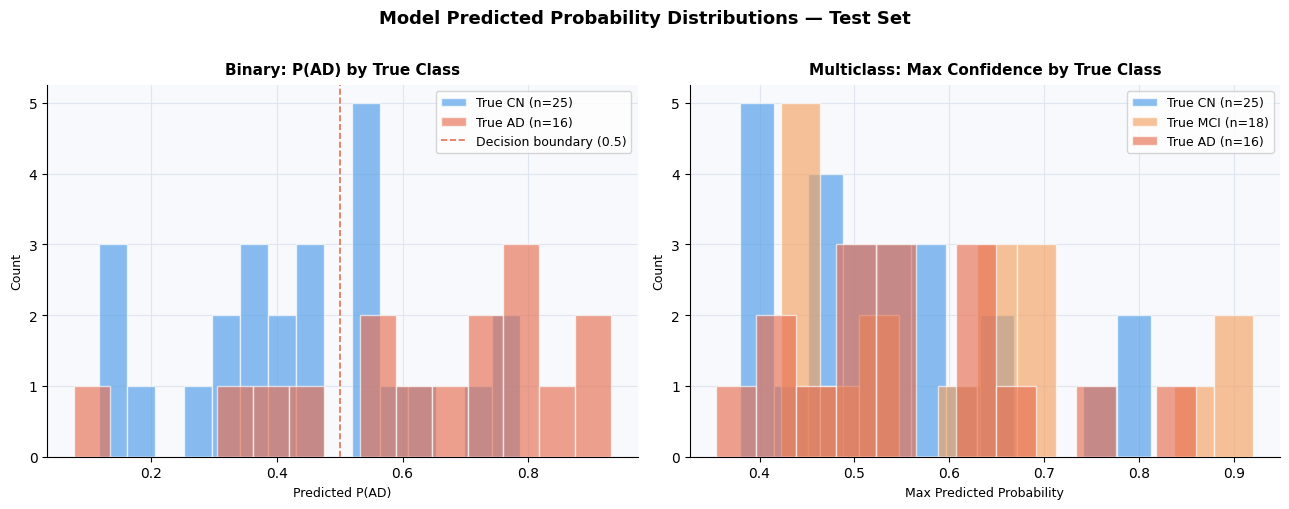

✅ Fig 7/7 — Probability Distributions


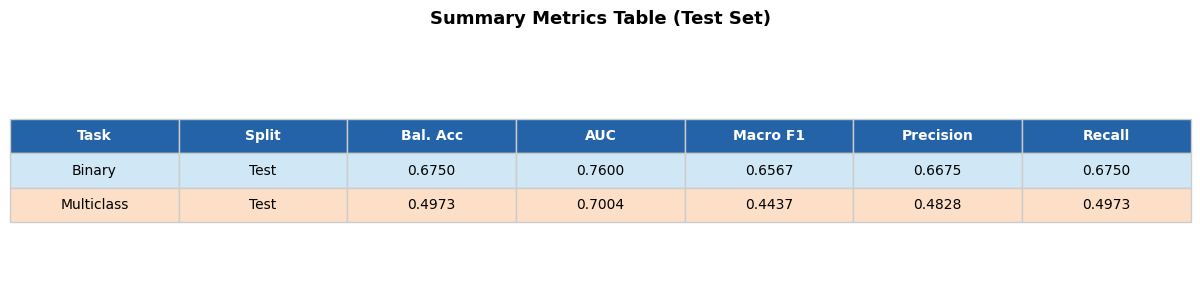

✅ Fig 8/8 — Summary Table

⏳ Saving PDF report → /content/drive/MyDrive/CerebroAI_Evaluation_Report_TestOnly.pdf
✅ PDF saved: /content/drive/MyDrive/CerebroAI_Evaluation_Report_TestOnly.pdf


In [20]:
# =============================================================================
# CELL 13 — Comprehensive Performance Evaluation Report (Test Set Only)
# Generates all metrics + visualizations for both binary and multiclass tasks.
#
# Automatically reads your PyTorch models and dataloaders from prior cells:
#   binary_model  |  b_test_loader  |  binary_classes
#   multi_model   |  m_test_loader  |  multi_classes
# =============================================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# ─── Palette ──────────────────────────────────────────────────────────────────
C_CN  = "#4C9BE8"   # blue
C_MCI = "#F4A261"   # orange
C_AD  = "#E76F51"   # red
C_BG  = "#F7F9FC"
C_GRID= "#E0E6EF"
PALETTE = [C_CN, C_AD]          # binary
PALETTE3= [C_CN, C_MCI, C_AD]   # multiclass

REPORT_PATH = '/content/drive/MyDrive/CerebroAI_Evaluation_Report_TestOnly.pdf'


# =============================================================================
# PyTorch Helper Utilities
# =============================================================================

def get_full_metrics_pytorch(model, dataloader, device, num_classes):
    """
    Runs inference on a PyTorch dataloader, extracts metrics,
    and uses a forward hook to grab deep features for PCA visualization.
    """
    model.eval()
    all_preds, all_labels, all_probs, all_feats = [], [], [], []

    # Hook to extract features from the layer right before the final FC
    features_dict = {}
    def hook_fn(m, i, o):
        features_dict['feats'] = o.detach()

    # Register hook on the ResNet avgpool layer
    handle = model.avgpool.register_forward_hook(hook_fn)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

            # Flatten the (B, 512, 1, 1) feature map to (B, 512)
            feats_flat = torch.flatten(features_dict['feats'], 1)
            all_feats.append(feats_flat.cpu().numpy())

    handle.remove() # Clean up the hook

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    all_feats  = np.vstack(all_feats)

    # Handle AUC depending on class count
    try:
        auc = (roc_auc_score(all_labels, all_probs[:, 1])
               if num_classes == 2
               else roc_auc_score(all_labels, all_probs, multi_class='ovr'))
    except Exception:
        auc = 0.0

    return {
        'y_true'   : all_labels,
        'preds'    : all_preds,
        'probs'    : all_probs,
        'features' : all_feats,
        'bal_acc'  : balanced_accuracy_score(all_labels, all_preds),
        'auc'      : auc,
        'macro_f1' : f1_score(all_labels, all_preds, average='macro'),
        'precision': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall'   : recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'cm'       : confusion_matrix(all_labels, all_preds),
        'report'   : classification_report(all_labels, all_preds, output_dict=True, zero_division=0),
    }

def styled_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(C_BG)
    ax.grid(True, color=C_GRID, linewidth=0.8, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    if title:  ax.set_title(title,  fontsize=11, fontweight='bold', pad=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)


# =============================================================================
# Visualizations
# =============================================================================

def fig_scorecard(b_test_m, m_test_m):
    tasks = [
        ("Binary  (CN vs AD)",         b_test_m),
        ("Multiclass (CN/MCI/AD)",      m_test_m),
    ]
    metrics_keys  = ['bal_acc', 'auc', 'macro_f1', 'precision', 'recall']
    metrics_labels= ['Bal. Accuracy', 'AUC (ROC)', 'Macro F1', 'Macro Precision', 'Macro Recall']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), facecolor='white')
    fig.suptitle("CerebroAI — Model Performance Scorecard (Test Set)", fontsize=14, fontweight='bold', y=1.01)

    bar_w = 0.4
    x     = np.arange(len(metrics_keys))

    for ax, (task_name, tm) in zip(axes, tasks):
        test_vals = [tm[k] for k in metrics_keys]
        b = ax.bar(x, test_vals, bar_w, label='Test (held-out)', color='#2563A8', edgecolor='white', zorder=3)

        for bar in b:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(metrics_labels, rotation=18, ha='right', fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color='#E76F51', linestyle='--', linewidth=1, label='Chance (0.50)', zorder=2)
        styled_ax(ax, title=task_name, ylabel='Score')
        ax.legend(fontsize=9, loc='upper right')

    plt.tight_layout()
    return fig


def fig_confusion_matrices(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')
    fig.suptitle("Confusion Matrices — Normalised (%)", fontsize=13, fontweight='bold', y=1.05)

    configs = [
        (axes[0], b_test_m['cm'], binary_classes, "Binary — Test", PALETTE),
        (axes[1], m_test_m['cm'], multi_classes,  "Multiclass — Test", PALETTE3),
    ]

    for ax, cm, classes, title, palette in configs:
        cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
        n = len(classes)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100, aspect='auto')

        for i in range(n):
            for j in range(n):
                raw  = cm[i, j]
                pct  = cm_norm[i, j]
                color= 'white' if pct > 55 else '#1A1A2E'
                ax.text(j, i, f'{pct:.1f}%\n({raw})', ha='center', va='center', fontsize=10, fontweight='bold', color=color)

        ax.set_xticks(range(n)); ax.set_xticklabels(classes, fontsize=10)
        ax.set_yticks(range(n)); ax.set_yticklabels(classes, fontsize=10, rotation=0)
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("Actual",    fontsize=9)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% of true class')

    plt.tight_layout()
    return fig


def fig_roc_curves(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("ROC Curves (Test Set)", fontsize=13, fontweight='bold', y=1.01)

    # Binary
    ax = axes[0]
    fpr, tpr, _ = roc_curve(b_test_m['y_true'], b_test_m['probs'][:, 1])
    ax.plot(fpr, tpr, '-', linewidth=2, label=f'Test AUC={b_test_m["auc"]:.3f}', color='#2563A8')
    ax.plot([0,1],[0,1],'--', color='#AAAAAA', linewidth=1, label='Chance')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#2563A8')
    styled_ax(ax, title='Binary (CN vs AD)', xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

    # Multiclass
    ax = axes[1]
    colors = [C_CN, C_MCI, C_AD]
    for i, cls in enumerate(multi_classes):
        y_bin = (m_test_m['y_true'] == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, m_test_m['probs'][:, i])
        auc_cls = roc_auc_score(y_bin, m_test_m['probs'][:, i])
        ax.plot(fpr, tpr, '-', linewidth=2, color=colors[i], label=f'{cls} vs Rest AUC={auc_cls:.3f}')

    ax.plot([0,1],[0,1],'--', color='#AAAAAA', linewidth=1, label='Chance')
    styled_ax(ax, title='Multiclass OvR', xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

    plt.tight_layout()
    return fig


def fig_pr_curves(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("Precision–Recall Curves (Test Set)", fontsize=13, fontweight='bold', y=1.01)

    # Binary
    ax = axes[0]
    prec, rec, _ = precision_recall_curve(b_test_m['y_true'], b_test_m['probs'][:, 1])
    ap = average_precision_score(b_test_m['y_true'], b_test_m['probs'][:, 1])
    ax.plot(rec, prec, '-', linewidth=2, color='#2563A8', label=f'AP={ap:.3f}')
    ax.fill_between(rec, prec, alpha=0.1, color='#2563A8')
    chance = b_test_m['y_true'].mean()
    ax.axhline(chance, color='#AAAAAA', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
    styled_ax(ax, title='Binary (CN vs AD)', xlabel='Recall', ylabel='Precision')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

    # Multiclass
    ax = axes[1]
    colors = [C_CN, C_MCI, C_AD]
    for i, cls in enumerate(multi_classes):
        y_bin = (m_test_m['y_true'] == i).astype(int)
        prec, rec, _ = precision_recall_curve(y_bin, m_test_m['probs'][:, i])
        ap = average_precision_score(y_bin, m_test_m['probs'][:, i])
        ax.plot(rec, prec, '-', linewidth=2, color=colors[i], label=f'{cls} AP={ap:.3f}')

    styled_ax(ax, title='Multiclass OvR', xlabel='Recall', ylabel='Precision')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

    plt.tight_layout()
    return fig


def fig_per_class(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("Per-Class Metrics — Test Set", fontsize=13, fontweight='bold', y=1.01)

    for ax, m, classes, palette, title in [
        (axes[0], b_test_m, binary_classes, PALETTE,  "Binary (CN vs AD)"),
        (axes[1], m_test_m, multi_classes,  PALETTE3, "Multiclass"),
    ]:
        report   = m['report']
        metrics  = ['precision', 'recall', 'f1-score']
        x        = np.arange(len(classes))
        bar_w    = 0.22
        offsets  = [-bar_w, 0, bar_w]
        labels   = ['Precision', 'Recall', 'F1-Score']
        colors   = ['#4C9BE8', '#63B995', '#E8A838']

        for k, (metric, offset, color, lbl) in enumerate(zip(metrics, offsets, colors, labels)):
            vals = [report[str(i)][metric] if str(i) in report else 0 for i in range(len(classes))]
            bars = ax.bar(x + offset, vals, bar_w, label=lbl, color=color, edgecolor='white', zorder=3)
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

        ax.set_xticks(x)
        ax.set_xticklabels(classes, fontsize=10)
        ax.set_ylim(0, 1.18)
        ax.axhline(0.5, color='#E76F51', linestyle='--', linewidth=0.8, label='Chance', zorder=2)
        styled_ax(ax, title=title, ylabel='Score')
        ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    return fig


def fig_feature_space(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("ResNet18 Feature Space — PCA Projection (Test Set)", fontsize=13, fontweight='bold', y=1.01)

    configs = [
        (axes[0], b_test_m['features'], b_test_m['y_true'], binary_classes, PALETTE,  "Binary"),
        (axes[1], m_test_m['features'], m_test_m['y_true'], multi_classes,  PALETTE3, "Multiclass"),
    ]

    for ax, X, y, classes, palette, title in configs:
        pca2 = PCA(n_components=2, random_state=42)
        try:
            X2   = pca2.fit_transform(X)
            var  = pca2.explained_variance_ratio_

            for i, (cls, color) in enumerate(zip(classes, palette)):
                mask = y == i
                ax.scatter(X2[mask, 0], X2[mask, 1], c=color, label=f'{cls} (n={mask.sum()})',
                           alpha=0.75, s=55, edgecolors='white', linewidths=0.5, zorder=3)

            styled_ax(ax, title=f'{title}\nPC1 {var[0]*100:.1f}% var | PC2 {var[1]*100:.1f}% var',
                      xlabel='Principal Component 1', ylabel='Principal Component 2')
            ax.legend(fontsize=9, framealpha=0.9)
        except Exception as e:
            ax.text(0.5, 0.5, f"PCA Failed\n{str(e)}", ha='center', va='center')

    plt.tight_layout()
    return fig


def fig_prob_distribution(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("Model Predicted Probability Distributions — Test Set", fontsize=13, fontweight='bold', y=1.01)

    # Binary: histogram of P(AD) per true class
    ax = axes[0]
    for i, (cls, color) in enumerate(zip(binary_classes, PALETTE)):
        mask = b_test_m['y_true'] == i
        ax.hist(b_test_m['probs'][mask, 1], bins=15, alpha=0.65, color=color, edgecolor='white',
                label=f'True {cls} (n={mask.sum()})', zorder=3)
    ax.axvline(0.5, color='#E76F51', linestyle='--', linewidth=1.2, label='Decision boundary (0.5)')
    styled_ax(ax, title='Binary: P(AD) by True Class', xlabel='Predicted P(AD)', ylabel='Count')
    ax.legend(fontsize=9)

    # Multiclass: max-probability (confidence) by true class
    ax = axes[1]
    max_probs = m_test_m['probs'].max(axis=1)
    for i, (cls, color) in enumerate(zip(multi_classes, PALETTE3)):
        mask = m_test_m['y_true'] == i
        ax.hist(max_probs[mask], bins=12, alpha=0.65, color=color, edgecolor='white',
                label=f'True {cls} (n={mask.sum()})', zorder=3)
    styled_ax(ax, title='Multiclass: Max Confidence by True Class', xlabel='Max Predicted Probability', ylabel='Count')
    ax.legend(fontsize=9)

    plt.tight_layout()
    return fig


def fig_summary_table(b_test_m, m_test_m):
    fig, ax = plt.subplots(figsize=(12, 3), facecolor='white')
    ax.axis('off')
    fig.suptitle("Summary Metrics Table (Test Set)", fontsize=13, fontweight='bold', y=0.98)

    col_labels = ['Task', 'Split', 'Bal. Acc', 'AUC', 'Macro F1', 'Precision', 'Recall']
    rows = [
        ["Binary",          "Test",
         f'{b_test_m["bal_acc"]:.4f}',f'{b_test_m["auc"]:.4f}',
         f'{b_test_m["macro_f1"]:.4f}',f'{b_test_m["precision"]:.4f}',
         f'{b_test_m["recall"]:.4f}'],
        ["Multiclass",  "Test",
         f'{m_test_m["bal_acc"]:.4f}',f'{m_test_m["auc"]:.4f}',
         f'{m_test_m["macro_f1"]:.4f}',f'{m_test_m["precision"]:.4f}',
         f'{m_test_m["recall"]:.4f}'],
    ]

    row_colors = [['#D0E8F5']*7, ['#FCDFC6']*7]

    tbl = ax.table(cellText=rows, colLabels=col_labels, cellLoc='center', loc='center', cellColours=row_colors)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 2.0)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#CCCCCC')
        if r == 0:
            cell.set_facecolor('#2563A8')
            cell.set_text_props(color='white', fontweight='bold')

    plt.tight_layout()
    return fig


# =============================================================================
# MAIN EXECUTOR
# =============================================================================

print("=" * 62)
print("📊  CerebroAI — Evaluation Report (Test Results Only)")
print("=" * 62)

print("\n⏳ Computing test metrics & extracting deep features for all tasks...")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
b_test_m = get_full_metrics_pytorch(binary_model, b_test_loader, device, num_classes=2)
m_test_m = get_full_metrics_pytorch(multi_model, m_test_loader, device, num_classes=3)
print("✅ Metrics ready\n")

print("── Binary Classification Report (Test) ──────────────────────")
print(classification_report(b_test_m['y_true'], b_test_m['preds'], target_names=binary_classes, zero_division=0))
print("\n── Multiclass Classification Report (Test) ───────────────────")
print(classification_report(m_test_m['y_true'], m_test_m['preds'], target_names=multi_classes, zero_division=0))

print("\n⏳ Rendering figures...\n")

figs = []
figs.append(fig_scorecard(b_test_m, m_test_m))
plt.show(); print("✅ Fig 1/7 — Scorecard")

figs.append(fig_confusion_matrices(b_test_m, m_test_m, binary_classes, multi_classes))
plt.show(); print("✅ Fig 2/7 — Confusion Matrices")

figs.append(fig_roc_curves(b_test_m, m_test_m, binary_classes, multi_classes))
plt.show(); print("✅ Fig 3/7 — ROC Curves")

figs.append(fig_pr_curves(b_test_m, m_test_m, binary_classes, multi_classes))
plt.show(); print("✅ Fig 4/7 — Precision-Recall Curves")

figs.append(fig_per_class(b_test_m, m_test_m, binary_classes, multi_classes))
plt.show(); print("✅ Fig 5/7 — Per-Class Metrics")

figs.append(fig_feature_space(b_test_m, m_test_m, binary_classes, multi_classes))
plt.show(); print("✅ Fig 6/7 — Deep Feature Space (PCA 2D)")

figs.append(fig_prob_distribution(b_test_m, m_test_m, binary_classes, multi_classes))
plt.show(); print("✅ Fig 7/7 — Probability Distributions")

figs.append(fig_summary_table(b_test_m, m_test_m))
plt.show(); print("✅ Fig 8/8 — Summary Table")

print(f"\n⏳ Saving PDF report → {REPORT_PATH}")
with PdfPages(REPORT_PATH) as pdf:
    for fig_obj in figs:
        pdf.savefig(fig_obj, bbox_inches='tight', facecolor='white')
        plt.close(fig_obj)

    d = pdf.infodict()
    d['Title']   = 'CerebroAI — Evaluation Report (Test)'
    d['Author']  = 'CerebroAI Pipeline'

print(f"✅ PDF saved: {REPORT_PATH}")